## Импорт библиотек и загрузка данных

In [1]:
# импорт библиотек и загрузка данных
import pandas as pd

df = pd.read_csv("hh_vacancies_v2.csv")
print(f"Загружено: {len(df)} вакансий")
print(f"Вакансий с требованиями: {df['requirement'].str.len().gt(0).sum()}")
print(f"\nПример requirement:")
print(df['requirement'].dropna().iloc[0])

Загружено: 5348 вакансий
Вакансий с требованиями: 5332

Пример requirement:
...источниками <highlighttext>данных</highlighttext>. Опыт написания SQL-запросов на уровне CTE, оконных функций. Работали с Python для анализа и обработки <highlighttext>данных</highlighttext>. 


## EDA

In [2]:
# форма датафрейма — (строки, колонки)
df.shape

(5348, 17)

In [3]:
df.dtypes # просмотр типа файдов

query               object
id                   int64
name                object
employer            object
area                object
salary_from        float64
salary_to          float64
currency            object
experience          object
work_format         object
is_remote             bool
employment_form     object
url                 object
published_at        object
requirement         object
responsibility      object
salary_avg         float64
dtype: object

In [4]:
# первые 10 строк — просмотр данных
df.head(10)

,query,id,name,employer,area,salary_from,salary_to,currency,experience,work_format,is_remote,employment_form,url,published_at,requirement,responsibility,salary_avg
0,аналитик данных,131288686,Аналитик данных,Синергетик,Нижний Новгород,NaN,NaN,NaN,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/131288686,2026-06-09 10:02:05+03:00,...источниками <highlighttext>данных</highligh...,Составлять ТЗ для доработки базы <highlighttex...,NaN
1,аналитик данных,130991275,Аналитик данных,РН-ЧЕРНОЗЕМЬЕ,Курск,36900.0,48000.0,RUR,Нет опыта,На месте работодателя,False,Полная,https://hh.ru/vacancy/130991275,2026-06-09 09:42:23+03:00,Высшее образование. Знание бухгалтерского учет...,Администрирование товарной базы <highlighttext...,42450.0
2,аналитик данных,133797122,Аналитик данных,Бэйби Опт Груп,Санкт-Петербург,NaN,NaN,NaN,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133797122,2026-06-09 08:40:13+03:00,Релевантный опыт работы от 1 года. Знание Exce...,Развитие структуры хранилища <highlighttext>да...,NaN
3,аналитик данных,134002238,Аналитик данных (ученик),Aston,Москва,80000.0,NaN,RUR,Нет опыта,Удалённо,True,Полная,https://hh.ru/vacancy/134002238,2026-06-09 11:00:12+03:00,Законченное высшее или среднее специальное про...,Онлайн-интенсив 1 месяц. Вы изучаете теорию и ...,80000.0
4,аналитик данных,133092825,Экономист аналитик/аналитик данных,Калье,Казань,NaN,NaN,NaN,От 3 до 6 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133092825,2026-06-09 10:00:47+03:00,...модели <highlighttext>данных</highlighttext...,...источникам <highlighttext>данных</highlight...,NaN
5,аналитик данных,133815699,Аналитик данных (антифрод),HeadHunter,Москва,NaN,NaN,NaN,От 1 года до 3 лет,"Удалённо, Гибрид",True,Полная,https://hh.ru/vacancy/133815699,2026-06-09 09:47:04+03:00,Опыт работы продуктовым <highlighttext>аналити...,Искать точки роста и генерировать гипотезы по ...,NaN
6,аналитик данных,133999133,Финансовый бизнес-аналитик/аналитик данных,ЛУКОЙЛ,Москва,NaN,NaN,NaN,От 3 до 6 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133999133,2026-06-09 10:17:49+03:00,Высшее экономическое или техническое образован...,Формирование глубокой <highlighttext>аналитики...,NaN
7,аналитик данных,133237516,Аналитик/Оператор базы данных,СИНЕРГИЯ,Москва,110000.0,110000.0,RUR,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133237516,2026-06-09 09:57:34+03:00,"Навыки работы с Excel и онлайн таблицами, форм...","ч. из CRM), подготовка справок о кандидатах и ...",110000.0
8,аналитик данных,134000821,Аналитик данных/системный аналитик 1С,Эгида,Казань,NaN,NaN,NaN,От 3 до 6 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/134000821,2026-06-09 10:38:38+03:00,"Продвинутое владение Excel, опыт работы с BI-и...","Разработка и настройка отчётов, работа с данны...",NaN
9,аналитик данных,134004442,Аналитик данных (в департамент маркетинга),ЧЭМК,Москва,120000.0,150000.0,RUR,От 1 года до 3 лет,"На месте работодателя, Гибрид",False,Полная,https://hh.ru/vacancy/134004442,2026-06-09 11:30:42+03:00,Навыки автоматизации сбора <highlighttext>данн...,Оптимизировать процессы сбора <highlighttext>д...,135000.0


In [5]:
# пропуски по колонкам — Series
df.isnull().sum()

query                 0
id                    0
name                  0
employer              0
area                  0
salary_from        3936
salary_to          4422
currency           3724
experience            0
work_format         104
is_remote             0
employment_form       0
url                   0
published_at          0
requirement          16
responsibility       18
salary_avg         3724
dtype: int64

#### Insight 
* 4474 раза — не определены пределы заработной платы
* 3842 раза — минимальный порог зарплаты
* 3633 раза — не указана страна (территориальное расположение)
* 3633 раза — средняя зарплата в этой категории

In [6]:
# Смотрим какие валюты есть
print(df['currency'].value_counts())

currency
RUR    1595
USD      21
EUR       7
BYR       1
Name: count, dtype: int64


In [7]:
# базовая статистика — DataFrame
df.describe()

,id,salary_from,salary_to,salary_avg
count,5.348000e+03,1412.000000,9.260000e+02,1.624000e+03
mean,1.329907e+08,135107.070113,1.865958e+05,1.542217e+05
std,2.381556e+06,83536.465097,3.393902e+05,1.519496e+05
min,6.734539e+07,150.000000,4.000000e+02,2.750000e+02
25%,1.329859e+08,80000.000000,1.000000e+05,8.750000e+04
50%,1.334780e+08,120000.000000,1.500000e+05,1.300000e+05
75%,1.338035e+08,170000.000000,2.500000e+05,2.000000e+05
max,1.340051e+08,700000.000000,1.000000e+07,5.100000e+06


In [8]:
# названия колонок — Index
df.columns

Index(['query', 'id', 'name', 'employer', 'area', 'salary_from', 'salary_to',
       'currency', 'experience', 'work_format', 'is_remote', 'employment_form',
       'url', 'published_at', 'requirement', 'responsibility', 'salary_avg'],
      dtype='object')

In [9]:
df = df.rename(columns={
    'query': 'category',
    'area': 'city',
    'name': 'sub-category',
    'requirement': 'skills_required',
    'responsibility': 'job_duties',
    'requirement_clean': 'skills_clean'
})
df.head()

,category,id,sub-category,employer,city,salary_from,salary_to,currency,experience,work_format,is_remote,employment_form,url,published_at,skills_required,job_duties,salary_avg
0,аналитик данных,131288686,Аналитик данных,Синергетик,Нижний Новгород,NaN,NaN,NaN,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/131288686,2026-06-09 10:02:05+03:00,...источниками <highlighttext>данных</highligh...,Составлять ТЗ для доработки базы <highlighttex...,NaN
1,аналитик данных,130991275,Аналитик данных,РН-ЧЕРНОЗЕМЬЕ,Курск,36900.0,48000.0,RUR,Нет опыта,На месте работодателя,False,Полная,https://hh.ru/vacancy/130991275,2026-06-09 09:42:23+03:00,Высшее образование. Знание бухгалтерского учет...,Администрирование товарной базы <highlighttext...,42450.0
2,аналитик данных,133797122,Аналитик данных,Бэйби Опт Груп,Санкт-Петербург,NaN,NaN,NaN,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133797122,2026-06-09 08:40:13+03:00,Релевантный опыт работы от 1 года. Знание Exce...,Развитие структуры хранилища <highlighttext>да...,NaN
3,аналитик данных,134002238,Аналитик данных (ученик),Aston,Москва,80000.0,NaN,RUR,Нет опыта,Удалённо,True,Полная,https://hh.ru/vacancy/134002238,2026-06-09 11:00:12+03:00,Законченное высшее или среднее специальное про...,Онлайн-интенсив 1 месяц. Вы изучаете теорию и ...,80000.0
4,аналитик данных,133092825,Экономист аналитик/аналитик данных,Калье,Казань,NaN,NaN,NaN,От 3 до 6 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133092825,2026-06-09 10:00:47+03:00,...модели <highlighttext>данных</highlighttext...,...источникам <highlighttext>данных</highlight...,NaN


## По спросу:

### Which direction has the most demand? — Какое направление самое востребованное?

In [10]:
# спрос по категориям — количество и % вакансий — DataFrame
metrics_by_category = (
    df.groupby('category')['id']
        .count()
        .sort_values(ascending=False ) 
        .reset_index(name ='count')
)
metrics_by_category['percent'] = (
    metrics_by_category['count']
    / metrics_by_category['count'].sum()
    *100
).round(2)

metrics_by_category


,category,count,percent
0,аналитик данных,2000,37.40
1,data analyst,1295,24.21
2,BI аналитик,1127,21.07
3,бизнес аналитик,926,17.31


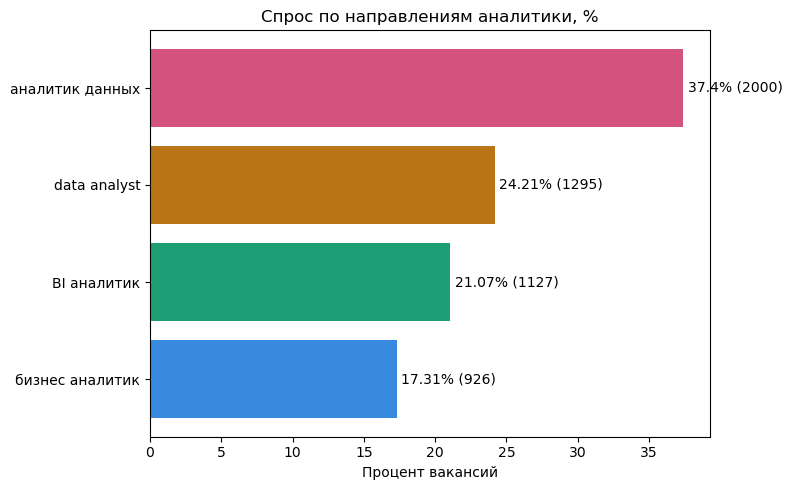

In [11]:
# визуализация спроса по категориям — barh
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    metrics_by_category['category'][::-1],
    metrics_by_category['percent'][::-1],
    color=['#378ADD', '#1D9E75', '#BA7517', '#D4537E']
)
ax.set_title('Спрос по направлениям аналитики, %')
ax.set_xlabel('Процент вакансий')
for i, (val, pct) in enumerate(zip(
    metrics_by_category['count'][::-1],
    metrics_by_category['percent'][::-1]
)):
    ax.text(pct + 0.3, i, f'{pct}% ({val})', va='center')
plt.tight_layout()
plt.savefig('category_demand.png', dpi=150)
plt.show()

In [12]:
# фильтр вакансий в рублях — проверка данных
df_rur = df[df['currency'] == 'RUR']
print(f"Вакансий с зарплатой в рублях: {len(df_rur)}")
print(f"Медиана salary_avg в рублях: {df_rur['salary_avg'].median():,.0f}")

Вакансий с зарплатой в рублях: 1595
Медиана salary_avg в рублях: 135,000


In [13]:
# рабочий датафрейм: рубли + зарплата > 10000 — DataFrame
df_salary = df[
    (df['currency'] == 'RUR') 
    & 
    (df['salary_avg'] > 10000)]
df_salary

,category,id,sub-category,employer,city,salary_from,salary_to,currency,experience,work_format,is_remote,employment_form,url,published_at,skills_required,job_duties,salary_avg
1,аналитик данных,130991275,Аналитик данных,РН-ЧЕРНОЗЕМЬЕ,Курск,36900.0,48000.0,RUR,Нет опыта,На месте работодателя,False,Полная,https://hh.ru/vacancy/130991275,2026-06-09 09:42:23+03:00,Высшее образование. Знание бухгалтерского учет...,Администрирование товарной базы <highlighttext...,42450.0
3,аналитик данных,134002238,Аналитик данных (ученик),Aston,Москва,80000.0,NaN,RUR,Нет опыта,Удалённо,True,Полная,https://hh.ru/vacancy/134002238,2026-06-09 11:00:12+03:00,Законченное высшее или среднее специальное про...,Онлайн-интенсив 1 месяц. Вы изучаете теорию и ...,80000.0
7,аналитик данных,133237516,Аналитик/Оператор базы данных,СИНЕРГИЯ,Москва,110000.0,110000.0,RUR,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133237516,2026-06-09 09:57:34+03:00,"Навыки работы с Excel и онлайн таблицами, форм...","ч. из CRM), подготовка справок о кандидатах и ...",110000.0
9,аналитик данных,134004442,Аналитик данных (в департамент маркетинга),ЧЭМК,Москва,120000.0,150000.0,RUR,От 1 года до 3 лет,"На месте работодателя, Гибрид",False,Полная,https://hh.ru/vacancy/134004442,2026-06-09 11:30:42+03:00,Навыки автоматизации сбора <highlighttext>данн...,Оптимизировать процессы сбора <highlighttext>д...,135000.0
11,аналитик данных,134003672,Аналитик,ЛАНИТ,Москва,150000.0,150000.0,RUR,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/134003672,2026-06-09 11:32:25+03:00,"...массивов, сложные формулы, сведение <highli...",...метрик для BI-отчетности. Постановка задач:...,150000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5332,бизнес аналитик,133747242,Главный кредитный аналитик,Банк ВТБ (ПАО),Курган,95000.0,NaN,RUR,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133747242,2026-06-02 13:28:51+03:00,Высшее экономическое образование. Опыт работы ...,"Проведение финансового анализа бизнеса, в том ...",95000.0
5333,бизнес аналитик,133786645,Методолог. Регламентация бизнеса,Создатель,Казань,50000.0,NaN,RUR,От 1 года до 3 лет,Удалённо,True,Полная,https://hh.ru/vacancy/133786645,2026-06-02 18:14:49+03:00,Не боится общаться с предпринимателями и руков...,Проводить Zoom-встречи с собственниками бизнес...,50000.0
5340,бизнес аналитик,133918608,Кредитный аналитик / андеррайтер (специалист п...,BANKON24,Тюмень,90000.0,NaN,RUR,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133918608,2026-06-05 17:56:47+03:00,Опыт работы в кредитовании юридических лиц или...,Проведение комплексного анализа финансового со...,90000.0
5345,бизнес аналитик,130361489,Бизнес-тренер/Тренинг-менеджер,Нмаркет.ПРО,Санкт-Петербург,100000.0,120000.0,RUR,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/130361489,2026-06-03 15:35:50+03:00,Высшее образование. Опыт работы от 2-х лет на ...,"Разработка и проведение тренингов, мастер-клас...",110000.0


### Наблюдение — hh.ru рынок аналитиков 2026
- Только 34% вакансий указывают зарплату
- Из них 96.6% в рублях
- Для анализа зарплат используем df_salary (1905 строк)

## По зарплатам:

### Which category pays the most? — Какое направление платит больше?

In [14]:
# зарплаты по категориям (mean, median, count) — DataFrame
salary_by_category = (
    df_salary.groupby('category')
        .agg(
            mean_salary= ('salary_avg' , 'mean'),
            median_salary=('salary_avg', 'median'),
            count=('salary_avg', 'count')
        )
    .reset_index()
    .sort_values('median_salary', ascending=False)
    .round(0)
)
salary_by_category

,category,mean_salary,median_salary,count
1,data analyst,205488.0,200000.0,286
0,BI аналитик,164451.0,150000.0,344
3,бизнес аналитик,158253.0,125000.0,333
2,аналитик данных,130657.0,115000.0,630


## Инсайт — зарплаты по направлениям (hh.ru, 9 июня 2026)
| Направление | Медиана | Вакансий |
|---|---|---|
| data analyst | 200к | 286 |
| BI аналитик | 150к | 344 |
| бизнес аналитик | 125к | 333 |
| аналитик данных | 115к | 630 |

**Вывод:** чем техничнее название — тем выше зарплата и меньше конкуренция

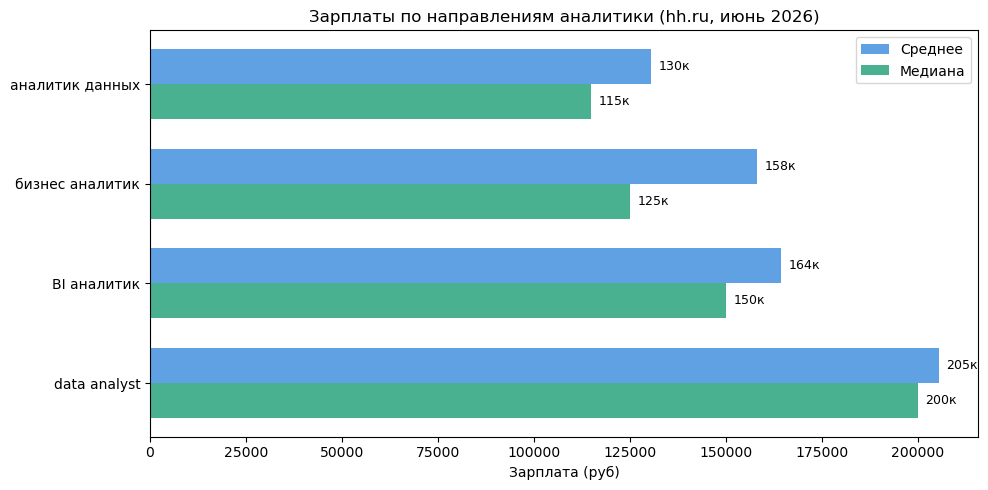

In [15]:
# визуализация зарплат по категориям (mean vs median) — grouped bar
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(salary_by_category))
width = 0.35

bars1 = ax.barh(
    [i + width/2 for i in x],
    salary_by_category['mean_salary'],
    width, label='Среднее', color='#378ADD', alpha=0.8
)
bars2 = ax.barh(
    [i - width/2 for i in x],
    salary_by_category['median_salary'],
    width, label='Медиана', color='#1D9E75', alpha=0.8
)

ax.set_yticks(x)
ax.set_yticklabels(salary_by_category['category'])
ax.set_xlabel('Зарплата (руб)')
ax.set_title('Зарплаты по направлениям аналитики (hh.ru, июнь 2026)')
ax.legend()

# Подписи значений
for bar in bars1:
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()/1000)}к', va='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()/1000)}к', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('salary_by_category.png', dpi=150)
plt.show()

**Инсайт:** mean всегда выше median → выбросы в зарплатах есть


### How does salary vary by experience? — Как зарплата меняется по опыту?

In [16]:
# медиана зарплат по категории и опыту — Series
experience_by_category = (df_salary
     .groupby(['category', 'experience'])['salary_avg']
     .median()
     .round(0)
)
experience_by_category


category         experience        
BI аналитик      Более 6 лет           275000.0
                 Нет опыта              90000.0
                 От 1 года до 3 лет    120000.0
                 От 3 до 6 лет         180000.0
data analyst     Более 6 лет           350000.0
                 Нет опыта             145000.0
                 От 1 года до 3 лет    134500.0
                 От 3 до 6 лет         240000.0
аналитик данных  Более 6 лет           205000.0
                 Нет опыта              70000.0
                 От 1 года до 3 лет    105000.0
                 От 3 до 6 лет         180000.0
бизнес аналитик  Более 6 лет           235000.0
                 Нет опыта              62500.0
                 От 1 года до 3 лет    110000.0
                 От 3 до 6 лет         175000.0
Name: salary_avg, dtype: float64

In [17]:
# медиана зарплат по категории и опыту — pivot table
experience_pivot = (df_salary
    .groupby(['category', 'experience'])['salary_avg']
    .median()
    .unstack('experience')
)
experience_pivot

experience,Более 6 лет,Нет опыта,От 1 года до 3 лет,От 3 до 6 лет
category,,,,
BI аналитик,275000.0,90000.0,120000.0,180000.0
data analyst,350000.0,145000.0,134500.0,240000.0
аналитик данных,205000.0,70000.0,105000.0,180000.0
бизнес аналитик,235000.0,62500.0,110000.0,175000.0


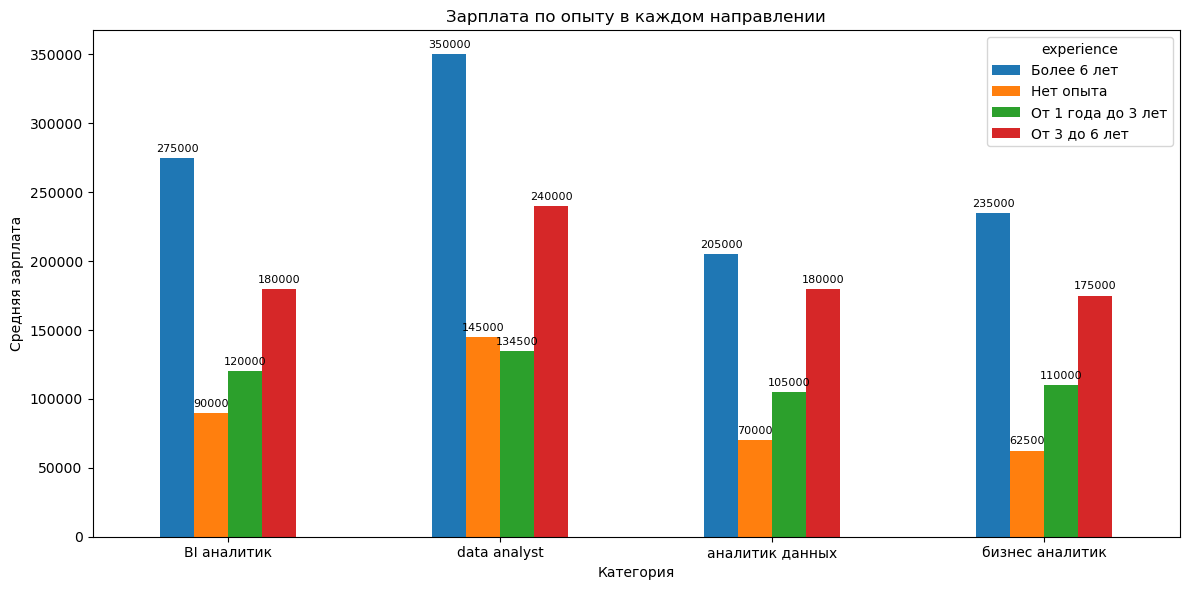

In [18]:
# визуализация зарплат по категории и опыту (grouped bar)
fig, ax = plt.subplots(figsize=(12, 6))
experience_pivot.plot(kind='bar', ax=ax)
ax.set_title('Зарплата по опыту в каждом направлении')
ax.set_xlabel('Категория')
ax.set_ylabel('Средняя зарплата')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=8, padding=3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Инсайт — зарплаты по опыту и направлениям (hh.ru, 9 июня 2026)

| Направление | Нет опыта | 1-3 года | 3-6 лет | 6+ лет |
|---|---|---|---|---|
| data analyst | 145к | 135к | 240к | 350к |
| BI аналитик | 90к | 120к | 180к | 275к |
| бизнес аналитик | 63к | 110к | 175к | 235к |
| аналитик данных | 70к | 105к | 180к | 205к |
**Вывод:** чем техничнее название — тем выше зарплата 
* У data analyst нет опыта = 145к — это больше чем у аналитик данных с опытом 1-3 года (105к). Это сильный инсайт!
* Рост от junior к senior у data analyst самый крутой: 145к → 350к (x2.4)
* У бизнес аналитик нет опыта = 63к — самый низкий входной порог

# По навыкам:

### What skills are most in demand? — Какие навыки самые востребованные?

In [19]:
import re

# очистка HTML и подсчёт навыков по списку — DataFrame
df['skills_clean'] = df['skills_required'].str.replace(
    r'<[^>]+>', '', regex=True
)

# список навыков для поиска
skills = [
    'SQL', 'Python', 'Power BI', 'DataLens', 'Tableau',
    'Excel', 'pandas', 'Airflow', 'Redash', 'Superset',
    'PostgreSQL', 'MySQL', 'ClickHouse', 'Spark',
    'Git', 'Kafka', 'dbt', 'Metabase'
]

# сколько раз каждый навык встречается
skill_counts = {}
for skill in skills:
    count = df['skills_clean'].str.contains(skill, case=False, na=False).sum()
    skill_counts[skill] = count

skills_df = pd.DataFrame(skill_counts.items(), columns=['skill', 'count'])
skills_df = skills_df.sort_values('count', ascending=False)
print(skills_df)

         skill  count
0          SQL    813
5        Excel    782
2     Power BI    446
1       Python    363
4      Tableau    165
6       pandas     86
14         Git     82
12  ClickHouse     75
10  PostgreSQL     73
9     Superset     55
3     DataLens     54
13       Spark     43
15       Kafka     33
7      Airflow     32
11       MySQL     21
17    Metabase     19
16         dbt      7
8       Redash      4


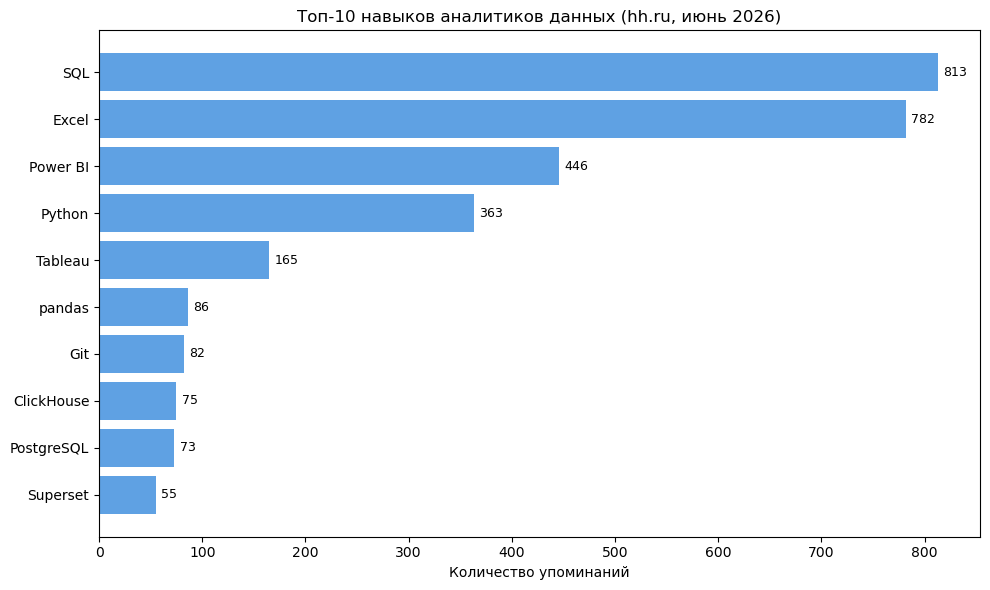

In [20]:
# визуализация топ-10 навыков — barh
top10 = skills_df.head(10)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top10['skill'][::-1],
    top10['count'][::-1],
    color='#378ADD', alpha=0.8
)

ax.set_xlabel('Количество упоминаний')
ax.set_title('Топ-10 навыков аналитиков данных (hh.ru, июнь 2026)')

# Подписи значений
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('skills_top10.png', dpi=150)
plt.show()

### BI vs Data Analyst — сравнение навыков

In [21]:
# фильтр двух категорий для сравнения навыков — DataFrame
df_bi = df[df['category'] == 'BI аналитик']
df_da = df[df['category'] == 'аналитик данных']

In [22]:
# подсчёт навыков для BI и DA раздельно — dict
skill_counts_bi = {}
skill_counts_da = {}

for skill in skills:
    skill_counts_bi[skill] = df_bi['skills_clean'].str.contains(
        skill, case=False, na=False).sum()
    skill_counts_da[skill] = df_da['skills_clean'].str.contains(
        skill, case=False, na=False).sum()

# Шаг 3 — объединяем в один DataFrame
compare_df = pd.DataFrame({
    'skill': list(skills),
    'BI аналитик': list(skill_counts_bi.values()),
    'аналитик данных': list(skill_counts_da.values())
})

compare_df = compare_df.sort_values(
    'BI аналитик', ascending=False
).head(10).reset_index(drop=True)
print(compare_df.head(10))

      skill  BI аналитик  аналитик данных
0  Power BI          364               51
1     Excel          297              365
2       SQL          159              389
3   Tableau          131               16
4    Python           66              158
5  DataLens           42                6
6  Superset           34               14
7       Git           24               18
8  Metabase           11                2
9    pandas           10               45


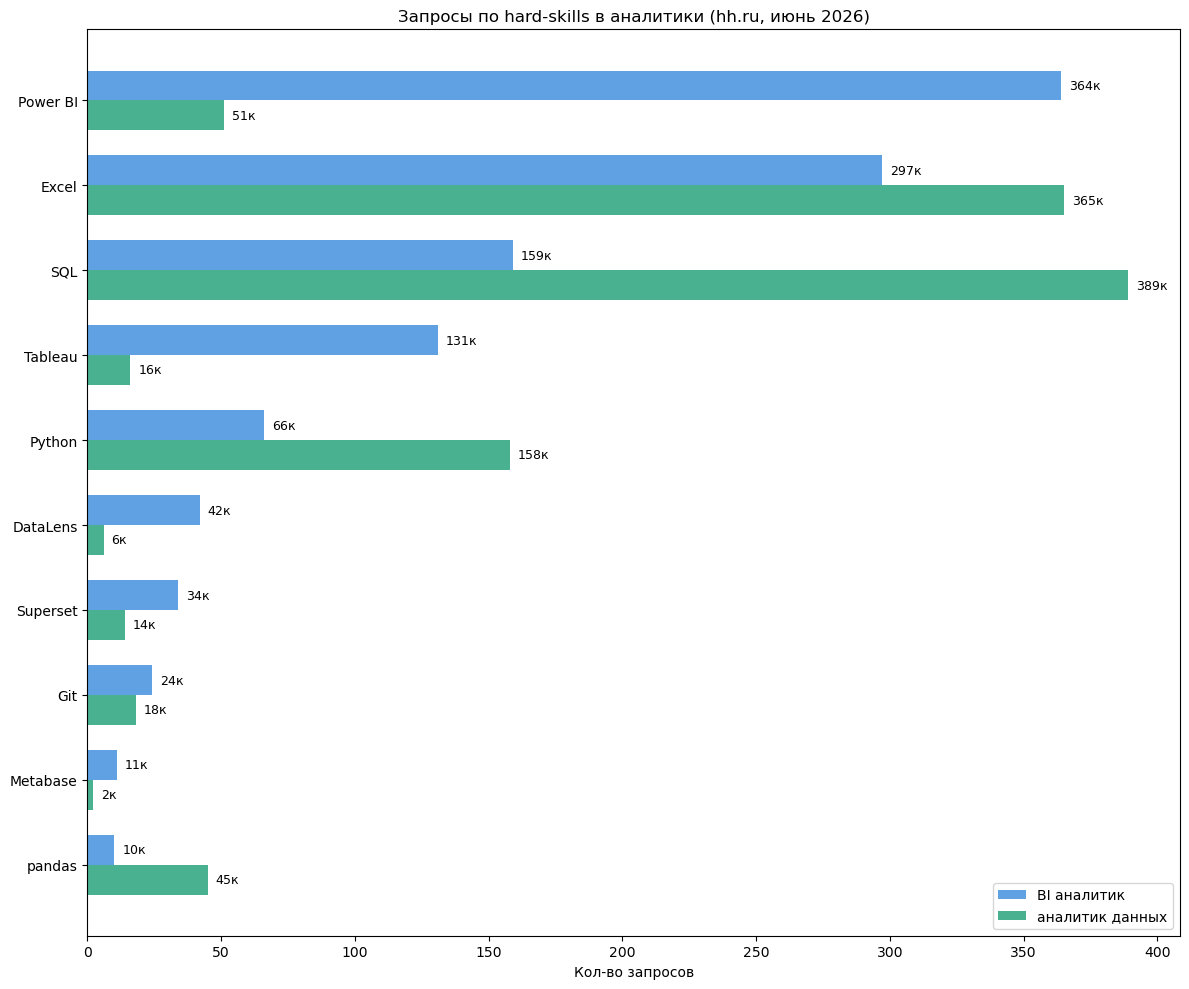

In [23]:
# визуализация сравнения навыков BI vs DA — grouped barh
compare_df = compare_df.sort_values(
    'BI аналитик', ascending=True  # ← меняем на True
).head(10).reset_index(drop=True).head(10)

fig, ax = plt.subplots(figsize=(12, 10))

x = range(len(compare_df))
width = 0.35

bars1 = ax.barh(
    [i + width/2 for i in x],
    compare_df['BI аналитик'],
    width, label='BI аналитик', color='#378ADD', alpha=0.8
)
bars2 = ax.barh(
    [i - width/2 for i in x],
    compare_df['аналитик данных'],
    width, label='аналитик данных', color='#1D9E75', alpha=0.8
)

ax.set_yticks(x)
ax.set_yticklabels(compare_df['skill'])
ax.set_xlabel('Кол-во запросов')
ax.set_title('Запросы по hard-skills в аналитики (hh.ru, июнь 2026)')
ax.legend()

# Подписи значений
for bar in bars1:
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}к', va='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}к', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('compare_df.png', dpi=150)
plt.show()

## Инсайт — BI vs Data Analyst стек (hh.ru, июнь 2026)

| Навык | BI аналитик | Аналитик данных |
|---|---|---|
| Power BI | 364 | 51 |
| SQL | 159 | 389 |
| Python | 66 | 158 |
| Excel | 297 | 365 |

**Вывод:**
- BI аналитик = визуализация (Power BI, Tableau, DataLens)
- Аналитик данных = данные и код (SQL, Python, pandas)
- Excel и SQL нужны обоим — базовый минимум

## По географии:

### What % of vacancies show salary? — Какой % вакансий указывает зарплату?

In [24]:
# фильтр городов мин. 10 вакансий + % с зарплатой по городам — Series
city_counts = df['city'].value_counts()
top_cities = city_counts[city_counts >= 10].index

In [25]:
#  % вакансий с указанной зарплатой по городам — Series
salary_pct_city = (df
    .groupby('city')
    .apply(lambda x: x['salary_avg'].notna().mean() * 100, include_groups=False)
    .round(1)
    .sort_values(ascending=False)
)

salary_pct_city = salary_pct_city[salary_pct_city.index.isin(top_cities)]
salary_pct_city.head(10)

city
Ростов-на-Дону               77.8
Барнаул                      76.9
Хабаровск                    71.4
Набережные Челны             66.7
Владивосток                  64.7
Волгоград                    63.2
Киров (Кировская область)    62.5
Владимир                     62.5
Краснодар                    62.3
Калининград                  55.6
dtype: float64

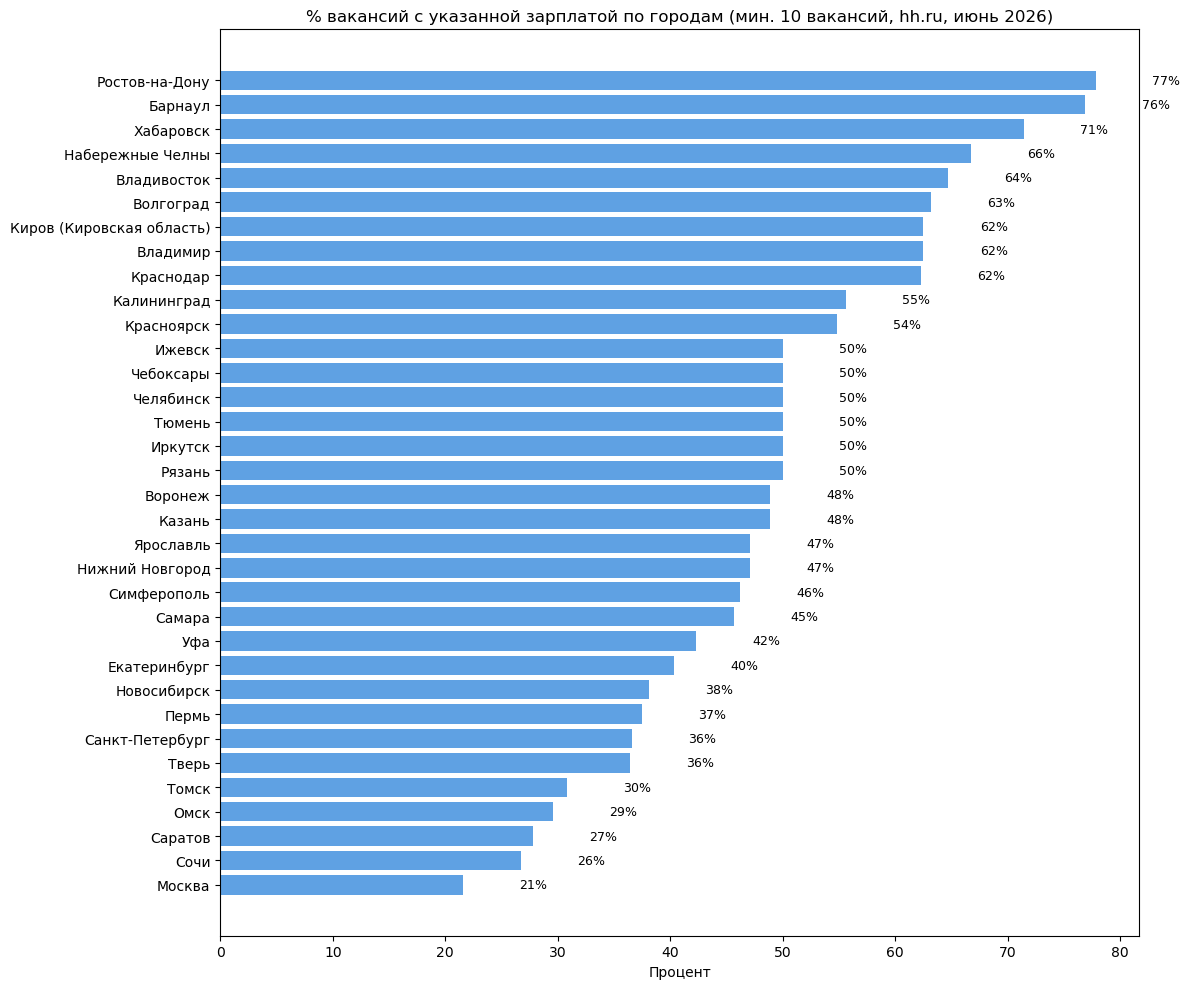

In [26]:
# визуализация % вакансий с зарплатой по городам — barh
top = salary_pct_city

fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.barh(
    top.index[::-1],
    top.values[::-1],
    color='#378ADD', alpha=0.8
)

ax.set_xlabel('Процент')
ax.set_title('% вакансий с указанной зарплатой по городам (мин. 10 вакансий, hh.ru, июнь 2026)')

# Подписи значений
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('salary_pct_city.png', dpi=150)
plt.show()

## Инсайт — % вакансий с указанной зарплатой по городам (hh.ru, 9 июня 2026)

| Город | % вакансий | 💡 |
|---|---|---|
| Ростов-на-Дону  | 77.8 | 👍 |
| Краснодар | 62.3 | 👍 |
| Санкт-Петербург | 36.6 | 🤔 |
| Москва | 21.6 | 🤔 |

**Вывод:** Регионы часто прозрачнее Москвы и Санкт-Петербурга 
* Ростов-на-дону - очень любит конкретику 
* в Краснодаре 62% вакансий показывают зарплату — это честный рынок, легче ориентироваться при поиске
* Москва всего 21.6% и Санкт-Петербург 36.6% — огромный рынок, но зарплаты скрывают


## Which cities have the highest salaries? — Какие города платят больше всего?

In [27]:
# медиана зарплат по городам — Series
salary_m_by_city = (df
    .groupby('city')
    .apply(lambda x: x['salary_avg'].median(), include_groups=False)
    .round(1)
    .sort_values(ascending=False)
)

salary_m_by_city = salary_m_by_city[salary_m_by_city.index.isin(top_cities)]
salary_m_by_city

city
Москва                       170000.0
Санкт-Петербург              130000.0
Екатеринбург                 128750.0
Ижевск                       127500.0
Владивосток                  123000.0
Иркутск                      117000.0
Самара                       112500.0
Воронеж                      110000.0
Новосибирск                  107500.0
Краснодар                    104500.0
Челябинск                    102200.0
Казань                       100000.0
Рязань                       100000.0
Пермь                        100000.0
Тверь                        100000.0
Уфа                          100000.0
Омск                          97500.0
Красноярск                    97000.0
Набережные Челны              96615.0
Томск                         95000.0
Киров (Кировская область)     93750.0
Владимир                      92500.0
Нижний Новгород               92000.0
Тюмень                        85000.0
Калининград                   85000.0
Хабаровск                     85000.0
Волгогр

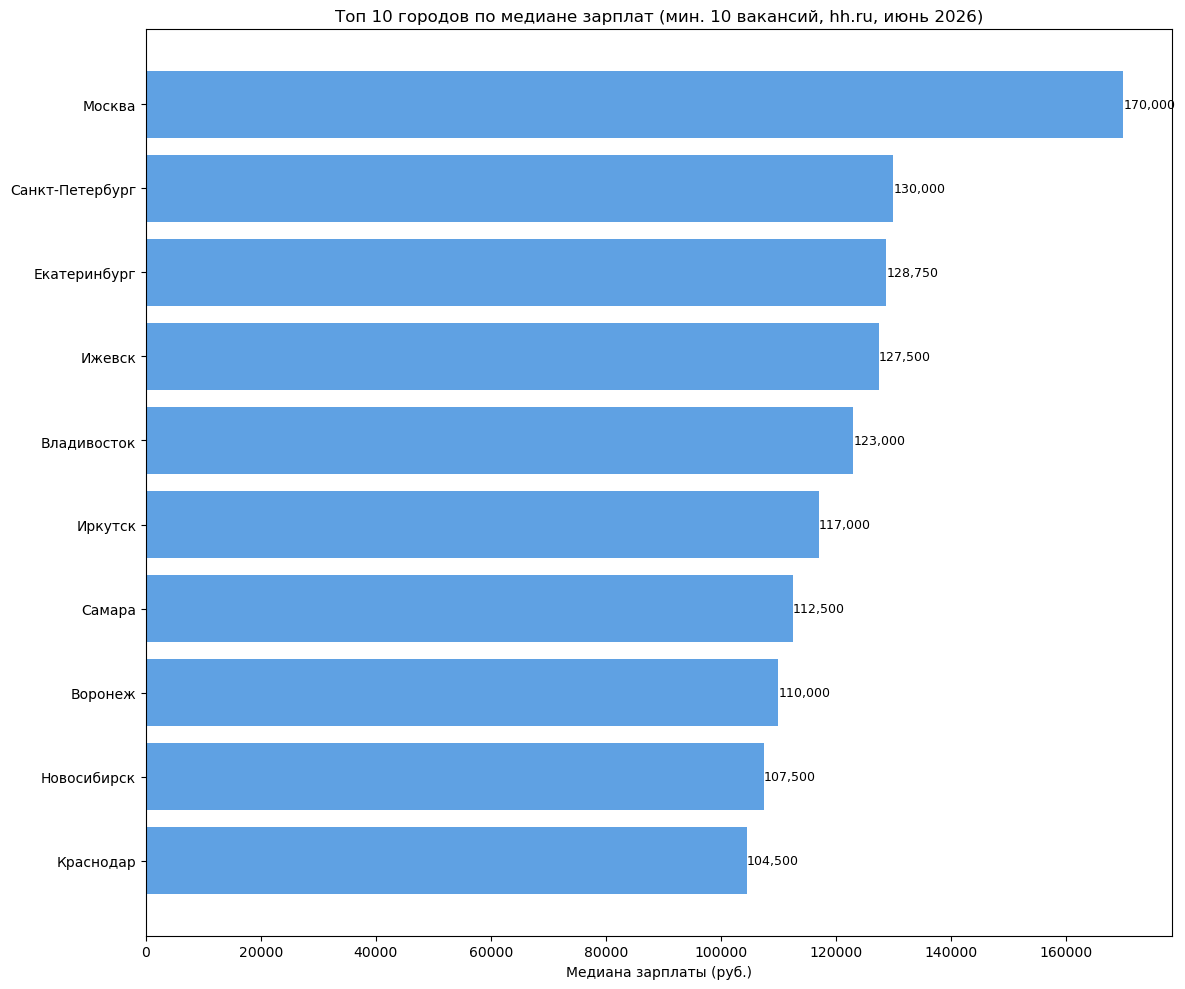

In [28]:
# визуализация топ-10 городов по медиане зарплат — barh
top = salary_m_by_city.head(10)

fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.barh(
    top.index[::-1],
    top.values[::-1],
    color='#378ADD', alpha=0.8
)

ax.set_xlabel('Медиана зарплаты (руб.)')
ax.set_title('Топ 10 городов по медиане зарплат (мин. 10 вакансий, hh.ru, июнь 2026)')

# Подписи значений
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('salary_m_by_city.png', dpi=150)
plt.show()

## Инсайт — медиана зарплаты по городам (hh.ru, 12 июня 2026)

| Город | медиана (руб.) | 💡 |
|---|---|---|
| Москва  | 170000 | 👍 |
| Санкт-Петербург| 130000 | 👍 |
| Краснодар | 104500 | 🤔 |
| Саратов | 70000| 🤔 |

**Вывод:** Регионы платят почти в два раза меньше Москвы и Санкт-Петербурга 
* За зарплатой в Москву !!! медиана 170000
* Краснодар (104к) обгоняет Саратов (70к) — не самый плохой рынок в регионах


# По географии:

## Which cities offer the most remote jobs? — Какие города дают больше всего удалённых вакансий?

In [29]:
# абсолютное количество удалённых вакансий по городам — Series
remote_by_city = (df[df['is_remote']]
    ['city']
    .value_counts()
    .head(15)
)
remote_by_city

city
Москва             983
Санкт-Петербург    144
Екатеринбург        41
Казань              34
Новосибирск         32
Нижний Новгород     26
Краснодар           12
Ростов-на-Дону      11
Пермь               10
Самара              10
Воронеж              9
Ижевск               7
Омск                 7
Ярославль            6
Рязань               5
Name: count, dtype: int64

In [30]:
# доля удалённых вакансий по городам — Series
remote_pct_city = (df
    .groupby('city')
    .apply(lambda x: x['is_remote'].mean() * 100, include_groups=False)
    .round(1)
    .sort_values(ascending=False)
)

remote_pct_city = remote_pct_city[remote_pct_city.index.isin(top_cities)]
remote_pct_city

city
Чебоксары                    50.0
Пермь                        41.7
Казань                       37.0
Ярославль                    35.3
Екатеринбург                 33.1
Ростов-на-Дону               30.6
Новосибирск                  30.5
Нижний Новгород              29.9
Самара                       28.6
Москва                       28.4
Калининград                  27.8
Рязань                       27.8
Ижевск                       26.9
Набережные Челны             26.7
Санкт-Петербург              26.4
Омск                         25.9
Владимир                     25.0
Киров (Кировская область)    25.0
Воронеж                      20.0
Краснодар                    19.7
Тюмень                       18.8
Тверь                        18.2
Симферополь                  15.4
Томск                        15.4
Барнаул                      15.4
Владивосток                  11.8
Уфа                          11.5
Саратов                      11.1
Волгоград                    10.5
Хабаровск

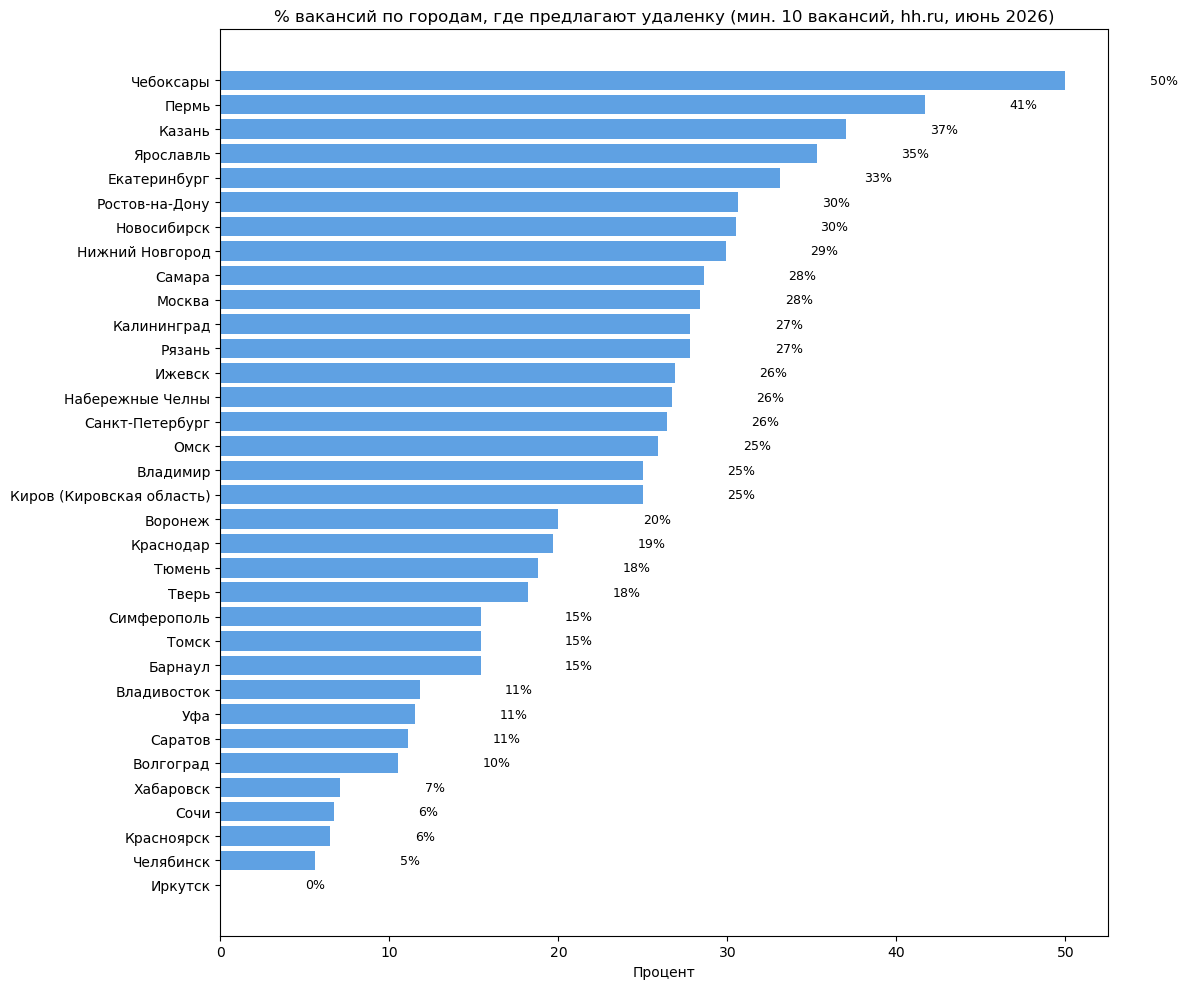

In [31]:
# доля удалённых вакансий по городам — barh
top = remote_pct_city

fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.barh(
    top.index[::-1],
    top.values[::-1],
    color='#378ADD', alpha=0.8
)

ax.set_xlabel('Процент')
ax.set_title('% вакансий по городам, где предлагают удаленку (мин. 10 вакансий, hh.ru, июнь 2026)')

# Подписи значений
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('remote_pct_city.png', dpi=150)
plt.show()

## Инсайт — % удалённых вакансий по городам (hh.ru, 9 июня 2026)

| Город | % удалённых | 💡 |
|---|---|---|
| Чебоксары | 50.0 | 👍 |
| Пермь | 41.7 | 👍 |
| Краснодар | 19.7 | 🤔 |
| Москва | 28.4 | 🤔 |

**Вывод:** больше всего удалённых вакансий предлагаю Москва, Санкт-Петербург и Екатеринбург, но по доли удаленных вакансий лидируют регионы
* Чебоксары 50% — каждая вторая вакансия удалённая, самый высокий показатель
* в Краснодаре 19% вакансий удаленно, остальное готовы видеть в офисе или гибрид
* меньше всего Челябинск


## How competitive is Krasnodar market? — Насколько конкурентен рынок Краснодара?

In [32]:
# количество вакансий: Краснодар vs топ города — Series
df['city'].value_counts().loc[['Краснодар', 'Москва', 'Санкт-Петербург', 'Екатеринбург']]

city
Краснодар            61
Москва             3461
Санкт-Петербург     546
Екатеринбург        124
Name: count, dtype: int64

In [33]:
# медиана зарплат: Краснодар vs топ города — Series
df_salary[df_salary['city'].isin(['Краснодар', 'Москва', 'Санкт-Петербург', 'Екатеринбург'])]\
    .groupby('city')['salary_avg'].median().round(0)

city
Екатеринбург       128750.0
Краснодар          104500.0
Москва             175000.0
Санкт-Петербург    130000.0
Name: salary_avg, dtype: float64

In [34]:
# распределение по опыту в Краснодаре — Series
df[df['city'] == 'Краснодар']['experience'].value_counts()

experience
От 1 года до 3 лет    42
От 3 до 6 лет         17
Нет опыта              2
Name: count, dtype: int64

## Инсайт — рынок Краснодара (hh.ru, 9 июня 2026)

| Показатель | Краснодар | Москва |
|---|---|---|
| Вакансий | 61 | 3461 |
| Медиана зарплаты | 104к | 175к |
| % с зарплатой | 62.3% | 21.6% |
| % удалёнки | 19.7% | 28.4% |

**Вывод:** Краснодар находится на пути развития IT-индустрии в сфере аналитики, в ~57 раз меньше вакансий, чем в  Москве
* среднее по зарплате почти в 2 раза меньше
* но есть плюсы процент предлагаемых вакансий с определенной зарплатой в 3 раза выше
* но удаленки меньше


## 🎯 Финальные выводы

### 📊 Рынок в целом
Рынок аналитики в России растёт, но конкуренция высокая.
«Аналитик данных» — самое популярное направление (37%), 
но с самым низким предложением по зарплате.
«Data analyst» — меньше вакансий (24%), но платят больше всех.
**Топ навыки:** SQL, Excel, Power BI — базовый минимум для входа.

### 💰 Зарплаты
Разброс огромный: Москва 170к vs Саратов 70к — разница в 2.5 раза.
При этом Москва и Питер часто скрывают зарплату (21% и 36%).
Рост от junior к senior у data analyst самый привлекательный: 145к → 350к (x2.4).
Самый низкий входной порог — бизнес аналитик (63к).

### 📍 Краснодар — не лидер, но и не аутсайдер
- 61 вакансия, медиана 104.5к
- 62.3% вакансий с указанной зарплатой — выше среднего
- Удалёнка только 19% — рынок офисный

### 🎯 Рекомендации
- **Прозрачность:** ищи в городах где указывают зарплату — Ростов, Краснодар, Барнаул
- **География:** не ограничивайся локальным рынком — удалёнка из Краснодара = московская зарплата
- **Минимум:** SQL + Excel обязательны, Power BI — конкурентное преимущество
- **Рост:** Python открывает data analyst — старт 145к, потолок 350к+